# Introduction to Confidence Intervals

### Objective:

- Understand what a Confidence Interval (CI) is in simple terms.

- Learn why CIs are useful in data analytics and decision-making.

Note: Use the `“Compare Answer”` toggle to check your responses. Your answer doesn’t need to be exact.


| Scenario                          | Distribution Used | When to Use                                                                                         | SciPy Function          |
| --------------------------------- | ----------------- | --------------------------------------------------------------------------------------------------- | ----------------------- |
| Population σ is **known**         | Z-distribution    | Data is normal and σ is known (rare in real life)                                                   | `stats.norm.interval()` |
| Population σ is **unknown**       | t-distribution    | Data is normal, σ unknown → use sample std dev. Especially important for **small samples (n < 30)** | `stats.t.interval()`    |
| Sample size is **large (n ≥ 30)** | Z-approximation   | By CLT, you can approximate with normal even if σ is unknown                                        | `stats.norm.interval()` |


# Case Study: Dosage Strength in a Pharmaceutical Company

Business Context

You work for a pharmaceutical company that produces medication tablets. The dosage strength is supposed to be consistent across tablets.

- The warehouse manager says the target average dosage is 50 mg and a standard deviation of 5mg.

- You’ve received a new batch of 100 tablets, and your task is to evaluate whether the batch is consistent with historical production.

## 1. What Data type are you working with?

- What type of data is dosage strength?

- Is it discrete or continuous?


Your answer here:



<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p>Data Type: Continuous (Dosage strength is measured in milligrams, which can take any value within a range)</p>
  
</details>

## 2. Identify the Analytical Question:

Your answer here:



<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p> Is the new batch consistent with the historical data? Specifically, what is the 95% confidence interval for the mean dosage strength of the new batch?</p>
  
</details>

In [3]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [4]:
df = pd.read_csv("data/dosage_strength.csv")

## 3. Calculate the Descriptive Stats

In [5]:
sample_mean = df['DosageStrength'].mean()
sample_std = df['DosageStrength'].std()
sample_median = df['DosageStrength'].median()
n = len(df)

print(f"Sample Mean: {sample_mean:.2f}")
print(f"Sample Standard Deviation: {sample_std:.2f}")
print(f"Sample Median: {sample_median:.2f}")

Sample Mean: 49.48
Sample Standard Deviation: 4.54
Sample Median: 49.37


## 4. Visualize the Data to check the Distribution

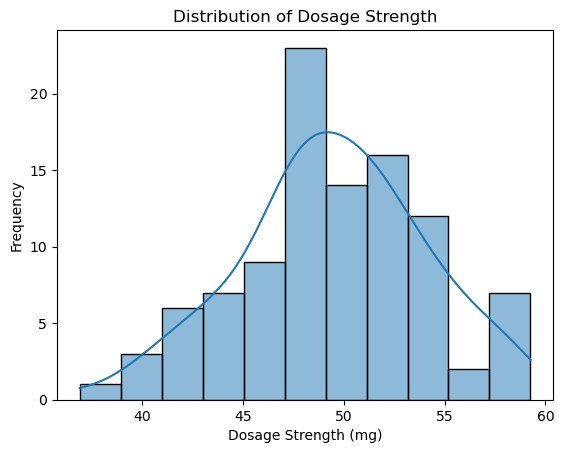

In [6]:
# Visualize the distribution
sns.histplot(df['DosageStrength'], kde=True)
plt.title("Distribution of Dosage Strength")
plt.xlabel("Dosage Strength (mg)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df['DosageStrength'].skew() # Checking skewness value  well within the expected bounds of  -0.5 and +0.5

np.float64(-0.17794814262595288)

## Interpret the Graph and Descriptive Statistics:

Your answer here:


<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p> Graph: The histogram should show a bell-shaped curve, confirming the normal distribution of the data.
  
Descriptive Statistics: The mean and median should be close to each other, further confirming the normality of the data.</p>
  
</details>

## 5.Check if Population Parameters are Known

Your answer here:


<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p> Population Mean (μ): Known (50 mg)
  
Population Standard Deviation (σ): Known (5 mg)</p>
  
</details>

## 6. Build the Confidence Interval

In [7]:
from scipy.stats import norm


In [ ]:
# 95% CI meaning we want to capture the middle 95% of the data. This leaves 5% of the data i.e. 2.5% on either tail
# Hence why we use .975 to establish upper bound of the CI and lower bound

z_score = norm.ppf(0.975) # Z-score since the data is normal and population params are known
margin_of_error = z_score * (5 / np.sqrt(n))  # 5 is the standard error 
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

print(f"95% Confidence Interval for the Mean Dosage Strength: ({ci_lower:.2f}, {ci_upper:.2f}) mg")

95% Confidence Interval for the Mean Dosage Strength: (48.50, 50.46) mg


In [9]:
# SciPy one-liner (assuming population std is known)
ci = norm.interval(0.95, loc=sample_mean, scale=5/np.sqrt(n))
print(f"SciPy norm.interval CI: {ci}")

SciPy norm.interval CI: (np.float64(48.500785420759506), np.float64(50.46074940529956))


## 7. Interpret in Business Terms

Question:

If the CI is (48.5, 50.5), what does this mean for the batch?

Is the batch dosage consistent with the target of 50 mg?


Your answer here:


<details>
  <summary>Compare Answer</summary>
  <h3>Answer:</h3>
  <p> 
   Since 50 mg lies inside the CI, the batch is consistent. If it was outside, we’d have evidence the batch is not aligned with the target.
</p>
  
</details>


### Interpretation of the Confidence Interval

The 95% confidence interval for the mean of our sample is (48.50, 50.46) mg. This means that we are 95% confident that the true population mean lies within this interval.

### What Does This Mean for Data Analytics?

In data analytics, confidence intervals help us make informed decisions. For example, if you're estimating the average customer satisfaction score, a confidence interval gives you a range where the true average score is likely to fall. This helps in making more accurate predictions and reducing uncertainty.
